# Data classes and problem parsing

In [1]:
import math
import random
import copy

class Node:
    def __init__(self, id, x, y, demand=0, tw_open=0, tw_close=float('inf'), service_time=0):
        self.id = id
        self.x = x
        self.y = y
        self.demand = demand
        self.tw_open = tw_open
        self.tw_close = tw_close
        self.service_time = service_time

class ProblemInstance:
    def __init__(self, capacity, depot, customers, num_vehicles=None, variant='none'):
        self.capacity = capacity
        self.depot = depot
        self.customers = customers
        self.nodes = [depot] + customers
        self.num_vehicles = num_vehicles
        self.variant = variant
        self.num_nodes = len(self.nodes)
        self.distance_matrix = self._compute_distance_matrix()

    def _compute_distance_matrix(self):
        matrix = [[0.0 for _ in range(self.num_nodes)] for _ in range(self.num_nodes)]
        for i, n1 in enumerate(self.nodes):
            for j, n2 in enumerate(self.nodes):
                matrix[i][j] = math.hypot(n1.x - n2.x, n1.y - n2.y)
        return matrix

def parse_cvrp(text):
    lines = [line.strip() for line in text.strip().split('\n') if line.strip()]
    capacity = float(lines[0])
    depot_data = list(map(float, lines[1].split()))
    depot = Node(0, depot_data[0], depot_data[1])
    
    customers = []
    for i, line in enumerate(lines[2:], start=1):
        data = list(map(float, line.split()))
        customers.append(Node(i, data[0], data[1], demand=data[2]))
        
    return ProblemInstance(capacity, depot, customers, variant='cvrp')

def parse_vrptw(text):
    lines = [line.strip() for line in text.strip().split('\n') if line.strip()]
    header = list(map(float, lines[0].split()))
    num_vehicles, capacity = int(header[0]), header[1]
    
    depot_data = list(map(float, lines[1].split()))
    depot = Node(0, depot_data[0], depot_data[1])
    
    customers = []
    for i, line in enumerate(lines[2:], start=1):
        data = list(map(float, line.split()))
        customers.append(Node(i, data[0], data[1], demand=data[2], 
                              tw_open=data[3], tw_close=data[4], service_time=data[5]))
        
    return ProblemInstance(capacity, depot, customers, num_vehicles, variant='vrptw')

# Helper functions

In [2]:
def calculate_heuristic(problem, current_node_idx, next_node_idx, current_time):
    """
    Calculates the heuristic desirability of moving to the next node.
    """
    dist = problem.distance_matrix[current_node_idx][next_node_idx]
    
    # Base case fallback to prevent division by zero
    if dist == 0:
        return 1.0 
    
    if problem.variant == 'vrptw':
        next_node = problem.nodes[next_node_idx]
        arrival_time = current_time + dist
        wait_time = max(0, next_node.tw_open - arrival_time)
        
        # In VRPTW, waiting is wasted time. We penalize distance and wait time.
        # 1e-6 to prevent division by zero
        return 1.0 / (dist + wait_time + 1e-6)
    elif problem.variant == 'cvrp':
        # Standard CVRP relies only on distance
        return 1.0 / dist

def evaluate_solution_cost(problem, routes, penalty_weight=10000.0):
    """
    Calculates the total cost of the routes and applies variant-specific penalties.
    """
    total_cost = 0.0
    
    # Calculate base distance cost
    for route in routes:
        for i in range(len(route) - 1):
            total_cost += problem.distance_matrix[route[i]][route[i+1]]
            
    # Apply VRPTW specific penalties
    if problem.variant == 'vrptw' and problem.num_vehicles is not None:
        if len(routes) > problem.num_vehicles:
            extra_vehicles = len(routes) - problem.num_vehicles
            # Heavy penalty to force ACO to find solutions within the vehicle limit
            total_cost += (extra_vehicles * penalty_weight)
            
    return total_cost

def is_feasible(problem, current_node_idx, next_node_idx, current_load, current_time):
    next_node = problem.nodes[next_node_idx]
    
    # Capacity Check
    if current_load + next_node.demand > problem.capacity:
        return False, 0, 0
    
    # Time Window Check for VRPTW
    travel_time = problem.distance_matrix[current_node_idx][next_node_idx]
    arrival_time = current_time + travel_time
    
    if problem.variant == 'vrptw':
        if arrival_time > next_node.tw_close:
            return False, 0, 0
        # Wait if arriving before time window opens
        wait_time = max(0, next_node.tw_open - arrival_time)
        new_time = arrival_time + wait_time + next_node.service_time
    elif problem.variant == 'cvrp':
        # In CVRP, time is total distance travelled
        new_time = arrival_time
        
    new_load = current_load + next_node.demand
    return True, new_load, new_time

def calculate_grasp_cost(problem, current_node_idx, next_node_idx, current_time):
    dist = problem.distance_matrix[current_node_idx][next_node_idx]
    
    if not problem.variant == 'vrptw':
        return dist # Standard CVRP just uses distance
        
    next_node = problem.nodes[next_node_idx]
    arrival_time = current_time + dist
    wait_time = max(0, next_node.tw_open - arrival_time)
    
    # Weight the cost: distance + waiting time + a penalty if the window closes soon
    urgency = next_node.tw_close - (arrival_time + wait_time)
    
    # You can tune these weights (alpha, beta, gamma) for better results
    return dist + wait_time + (1.0 / (urgency + 1.0))

# GRASP Solver

In [3]:
def solve_grasp(problem, alpha=0.3):
    unvisited = set(range(1, problem.num_nodes))
    routes = []
    total_cost = 0.0
    
    while unvisited:
        current_route = [0] # Start at depot
        current_node = 0
        current_load = 0.0
        current_time = 0.0
        
        while True:
            candidates = []
            for j in unvisited:
                feasible, new_load, new_time = is_feasible(problem, current_node, j, current_load, current_time)
                if feasible:
                    cost = calculate_grasp_cost(problem, current_node, j, current_time)
                    candidates.append((cost, j, new_load, new_time))
            
            if not candidates:
                break # Route is done, must return to depot
            
            # Sort by greedy cost (distance)
            candidates.sort(key=lambda x: x[0])
            
            # Form Restricted Candidate List (RCL)
            min_cost = candidates[0][0]
            max_cost = candidates[-1][0]
            threshold = min_cost + alpha * (max_cost - min_cost)
            
            rcl = [c for c in candidates if c[0] <= threshold]
            
            # Pick randomly from RCL
            chosen = random.choice(rcl)
            _, next_node, current_load, current_time = chosen
            
            current_route.append(next_node)
            unvisited.remove(next_node)
            current_node = next_node
            
        current_route.append(0) # End at depot
        routes.append(current_route)
        
        # Calculate cost for this route
        for i in range(len(current_route) - 1):
            total_cost += problem.distance_matrix[current_route[i]][current_route[i+1]]
            
    return routes, total_cost

# ACO Solver

In [4]:
def solve_aco(problem, num_ants=30, num_iterations=200, alpha=1, beta=3, evaporation=0.9, Q=100):
    num_nodes = problem.num_nodes
    pheromones = [[1.0 for _ in range(num_nodes)] for _ in range(num_nodes)]
    
    best_routes = None
    best_cost = float('inf')

    history = []
    
    for iteration in range(num_iterations):
        all_ant_routes = []
        all_ant_costs = []
        
        for ant in range(num_ants):
            unvisited = set(range(1, num_nodes))
            routes = []
            
            while unvisited:
                current_route = [0]
                current_node = 0
                current_load = 0.0
                current_time = 0.0
                
                while True:
                    feasible_moves = []
                    for j in unvisited:
                        # Feasibility
                        feasible, new_load, new_time = is_feasible(
                            problem, current_node, j, current_load, current_time
                        )
                        if feasible:
                            feasible_moves.append((j, new_load, new_time))
                            
                    if not feasible_moves:
                        break # Must return to depot
                        
                    probabilities = []
                    total_prob = 0.0
                    for j, _, _ in feasible_moves:
                        tau = pheromones[current_node][j]
                        
                        # Heuristic (eta)
                        eta = calculate_heuristic(problem, current_node, j, current_time)
                        
                        prob = (tau ** alpha) * (eta ** beta)
                        probabilities.append(prob)
                        total_prob += prob
                        
                    # Roulette wheel selection
                    rand_val = random.uniform(0, total_prob)
                    cumulative = 0.0
                    chosen_idx = -1
                    for i, prob in enumerate(probabilities):
                        cumulative += prob
                        if cumulative >= rand_val:
                            chosen_idx = i
                            break
                            
                    next_node, current_load, current_time = feasible_moves[chosen_idx]
                    current_route.append(next_node)
                    unvisited.remove(next_node)
                    current_node = next_node
                    
                current_route.append(0)
                routes.append(current_route)
                
            # Evaluate total cost with penalties
            total_cost = evaluate_solution_cost(problem, routes)
            
            all_ant_routes.append(routes)
            all_ant_costs.append(total_cost)
            
            if total_cost < best_cost:
                best_cost = total_cost
                best_routes = routes
                
        # Pheromone Update (Evaporation & Deposit)
        for i in range(num_nodes):
            for j in range(num_nodes):
                pheromones[i][j] *= (1.0 - evaporation)
                
        for routes, cost in zip(all_ant_routes, all_ant_costs):
            # If the cost is heavily penalized, the deposit is tiny, effectively ignoring bad routes
            deposit = Q / cost 
            for route in routes:
                for i in range(len(route) - 1):
                    from_node = route[i]
                    to_node = route[i+1]
                    pheromones[from_node][to_node] += deposit
                    pheromones[to_node][from_node] += deposit

        history.append(best_cost)

    return best_routes, best_cost, history

# Visualizations

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_routes(problem, routes, title="VRP Solution"):
    """
    Plots the nodes and the vehicle routes on a 2D scatter plot.
    """
    plt.figure(figsize=(10, 8))
    
    # Plot all customer nodes
    cust_x = [node.x for node in problem.customers]
    cust_y = [node.y for node in problem.customers]
    plt.scatter(cust_x, cust_y, c='blue', marker='o', s=30, label='Customers', zorder=2)
    
    # Plot the depot
    plt.scatter(problem.depot.x, problem.depot.y, c='red', marker='s', s=100, label='Depot', zorder=3)
    
    # Draw the routes
    colors = cm.rainbow(np.linspace(0, 1, len(routes)))
    
    for route_idx, route in enumerate(routes):
        route_x = [problem.nodes[node_idx].x for node_idx in route]
        route_y = [problem.nodes[node_idx].y for node_idx in route]
        
        plt.plot(route_x, route_y, color=colors[route_idx], linewidth=1.5, 
                 alpha=0.7, label=f'Vehicle {route_idx + 1}', zorder=1)
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    
    # Place legend outside the plot if there are many vehicles
    if len(routes) <= 10:
        plt.legend()
    else:
        plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
        
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_convergence(aco_cost_history, grasp_cost, title="ACO Convergence vs GRASP Baseline"):
    """
    Plots the cost improvement of ACO over iterations compared to the GRASP baseline.
    """
    plt.figure(figsize=(10, 6))
    
    iterations = range(1, len(aco_cost_history) + 1)
    
    # Plot ACO cost curve
    plt.plot(iterations, aco_cost_history, marker='o', markersize=4, 
             linestyle='-', color='purple', label='ACO Best Cost', linewidth=2)
    
    # Plot GRASP baseline as a horizontal line
    plt.axhline(y=grasp_cost, color='orange', linestyle='--', 
                label=f'GRASP Baseline ({grasp_cost:.2f})', linewidth=2)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Iteration')
    plt.ylabel('Total Route Cost')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def print_comparative_summary(problem_name, grasp_routes, grasp_cost, aco_routes, aco_cost):
    print("-" * 50)
    print(f"RESULTS SUMMARY: {problem_name}")
    print("-" * 50)
    print(f"{'Metric':<20} | {'GRASP Baseline':<15} | {'ACO Solver':<15}")
    print("-" * 50)
    print(f"{'Total Cost':<20} | {grasp_cost:<15.2f} | {aco_cost:<15.2f}")
    print(f"{'Vehicles Used':<20} | {len(grasp_routes):<15} | {len(aco_routes):<15}")
    
    cost_diff = grasp_cost - aco_cost
    pct_improvement = (cost_diff / grasp_cost) * 100 if grasp_cost > 0 else 0
    
    print("-" * 50)
    if cost_diff > 0:
        print(f"ACO improved upon GRASP by {pct_improvement:.2f}% ({cost_diff:.2f} cost units).")
    else:
        print(f"GRASP outperformed or tied ACO by {-pct_improvement:.2f}%. (Try tuning ACO parameters!)")
    print("-" * 50)

# Run problem instances

In [6]:
def cvrp():
    with open('cvrp.txt', 'r') as file:
        cvrp_text = file.read()
    problem = parse_cvrp(cvrp_text)

    aco_routes, aco_cost, history = solve_aco(problem)

    grasp_routes, grasp_cost = solve_grasp(problem)

    print_comparative_summary("CVRP", grasp_routes, grasp_cost, aco_routes, aco_cost)

    plot_routes(problem, grasp_routes, f"CVRP GRASP Solution (cost: {grasp_cost:.2f})")
    plot_routes(problem, aco_routes, f"CVRP ACO Solution (cost: {aco_cost:.2f})")

    plot_convergence(history, grasp_cost)

def vrptw():
    with open('vrptw.txt', 'r') as file:
        vrptw_text = file.read()
    problem = parse_vrptw(vrptw_text)

    aco_routes, aco_cost, history = solve_aco(problem)

    grasp_routes, grasp_cost = solve_grasp(problem)

    print_comparative_summary("VRPTW", grasp_routes, grasp_cost, aco_routes, aco_cost)

    plot_routes(problem, grasp_routes, f"VRPTW GRASP Solution (cost: {grasp_cost:.2f})")
    plot_routes(problem, aco_routes, f"VRPTW ACO Solution (cost: {aco_cost:.2f})")

    plot_convergence(history, grasp_cost)

--------------------------------------------------
RESULTS SUMMARY: CVRP
--------------------------------------------------
Metric               | GRASP Baseline  | ACO Solver     
--------------------------------------------------
Total Cost           | 1021.90         | 606.23         
Vehicles Used        | 5               | 5              
--------------------------------------------------
ACO improved upon GRASP by 40.68% (415.67 cost units).
--------------------------------------------------


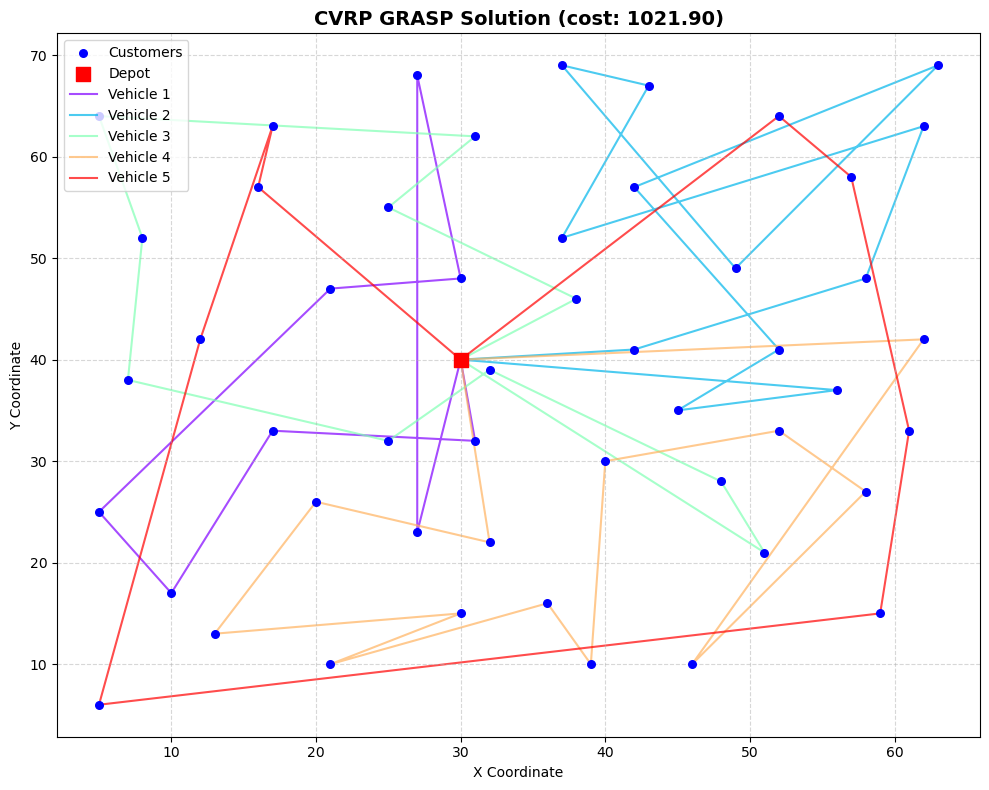

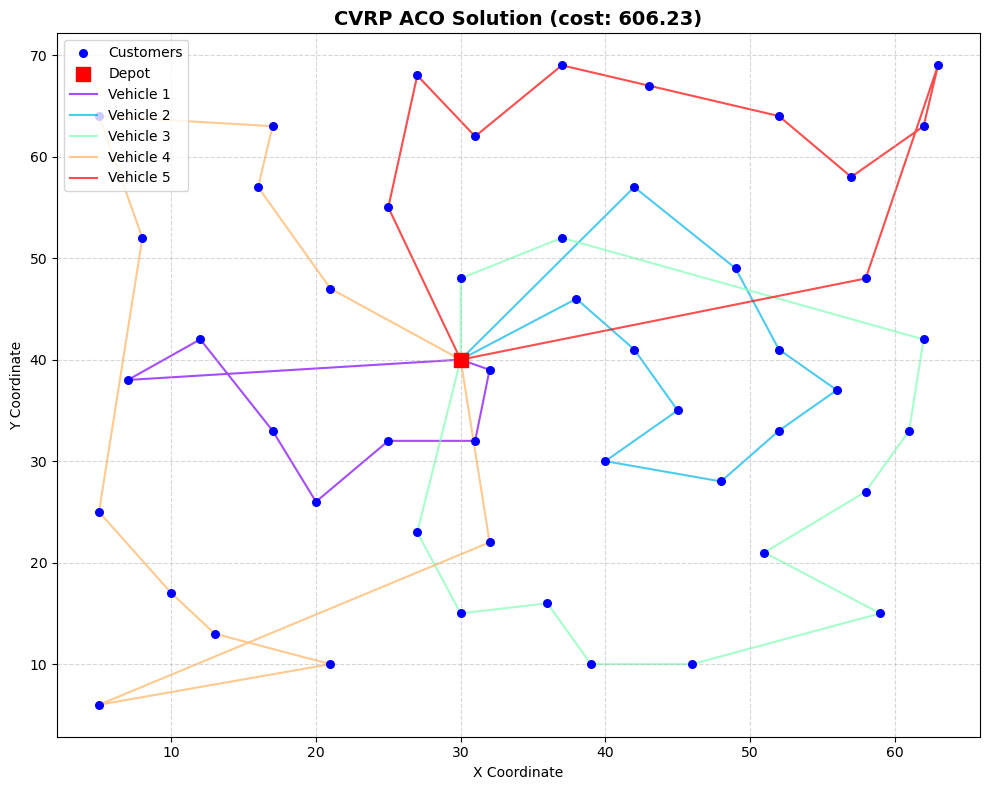

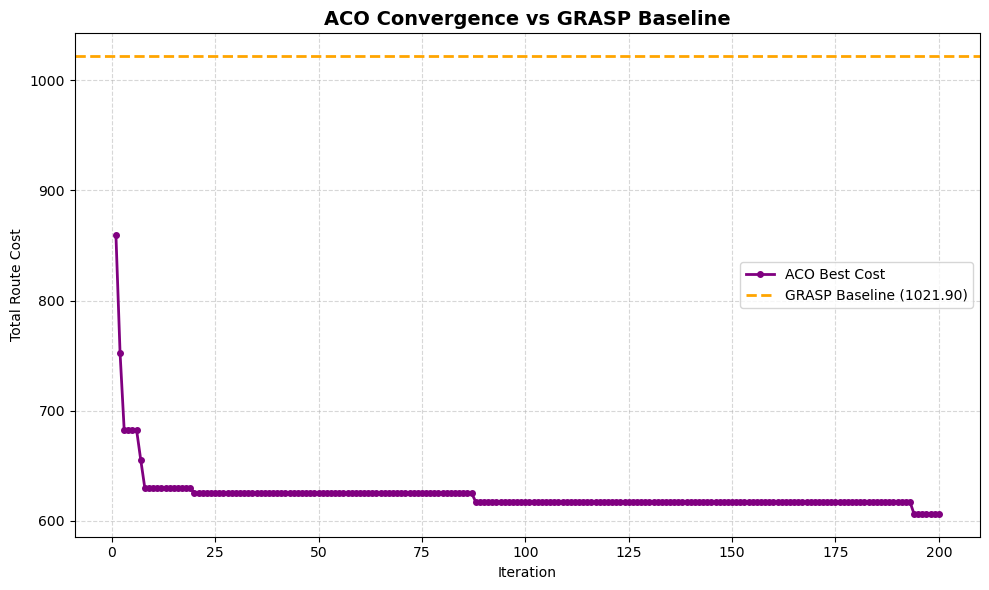

--------------------------------------------------
RESULTS SUMMARY: VRPTW
--------------------------------------------------
Metric               | GRASP Baseline  | ACO Solver     
--------------------------------------------------
Total Cost           | 3115.22         | 1903.73        
Vehicles Used        | 30              | 20             
--------------------------------------------------
ACO improved upon GRASP by 38.89% (1211.49 cost units).
--------------------------------------------------


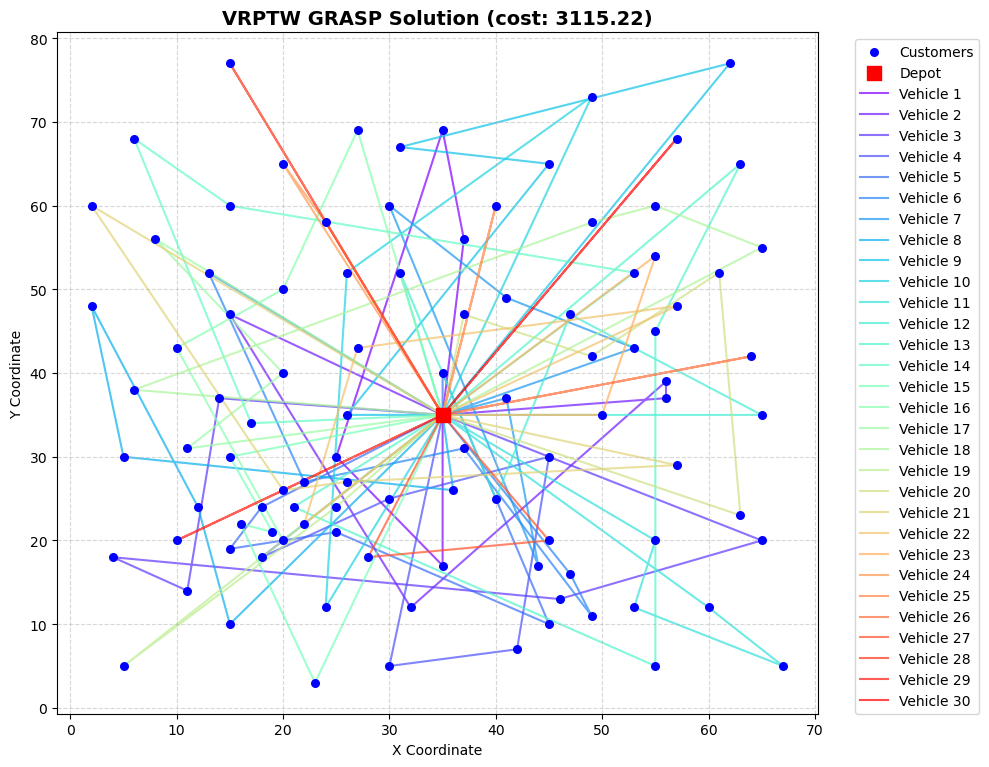

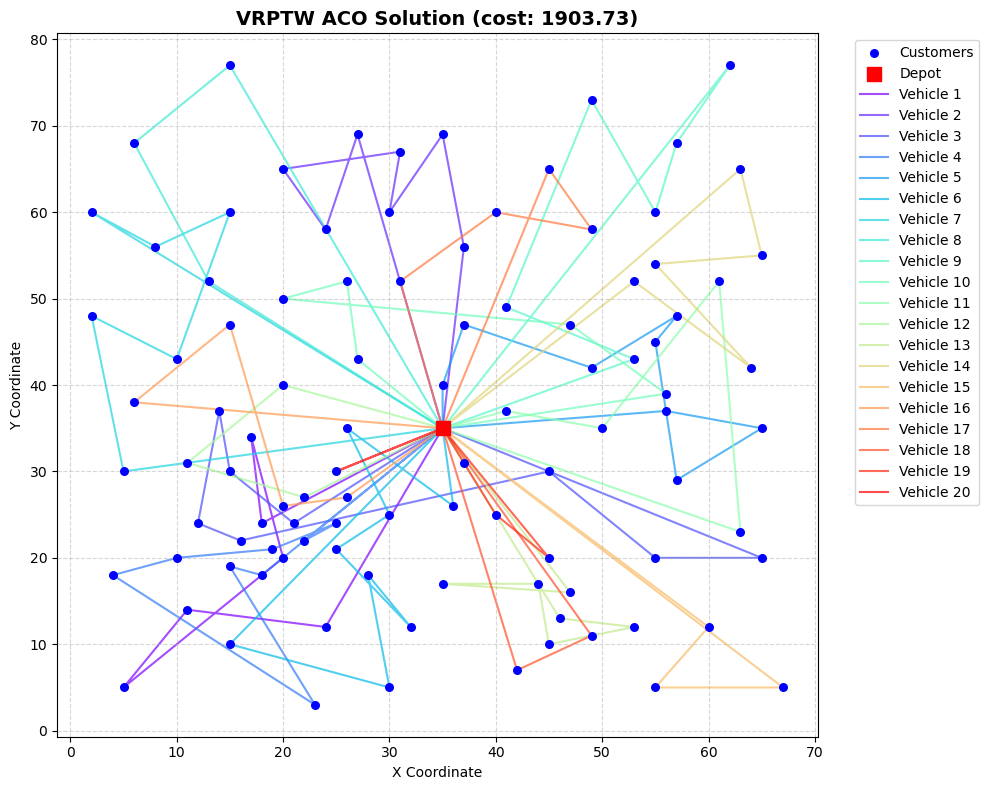

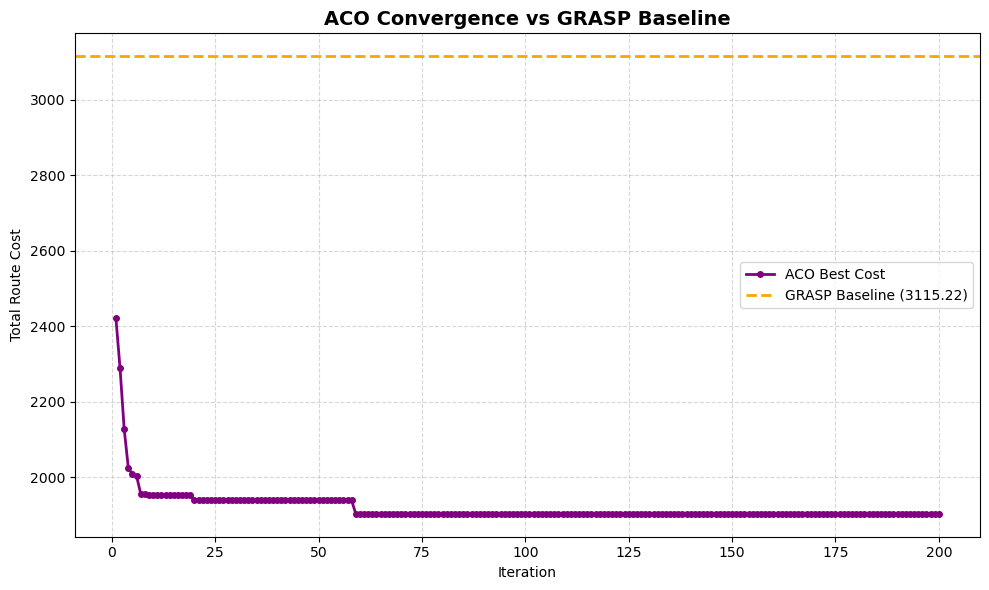

In [7]:
cvrp()
vrptw()

# Results
Through testing we can see that ACO is much better than GRASP (duh). Our implementation converges very fast, which might indicate pre-mature convergence. We have done a little hypreparameter tuning, though mostly focusing on the CVRP problem. The resulting parameters increased the performance compared to the GRASP implementation from 30% to around 40% better.